In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## Load dataset

In [6]:
data=load_breast_cancer()
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [15]:
X = data.data
X
y = data.target

In [12]:
X.shape
print("số lượng mẫu:", X.shape[0])
print("Số lượng đặc trưng:", X.shape[1])
print("các lớp:", data.target_names)

số lượng mẫu: 569
Số lượng đặc trưng: 30
các lớp: ['malignant' 'benign']


## Chia dữ liệu train/test

In [16]:
X_train, X_test, y_train, y_test=train_test_split(
X,y,test_size=0.2,
random_state=42,
stratify=y)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


In [20]:
model_overfit=DecisionTreeClassifier(max_depth=None, random_state=42)
model_overfit.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [21]:
train_pred=model_overfit.predict(X_train)
test_pred=model_overfit.predict(X_test)
train_accuracy=accuracy_score(y_train, train_pred)
test_accuracy=accuracy_score(y_test, test_pred)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9122807017543859


## Áp dụng K-fold cross validation

In [22]:
kfold=KFold(n_splits=5,shuffle=True, random_state=42)

In [24]:
cv_scores=cross_val_score(model_overfit,X,y,cv=kfold, scoring='accuracy')
print("Accuracy từng fold:")
print(cv_scores)
print("Mean Accuracy:",cv_scores.mean())
print("Standard Deviation:",
      cv_scores.std())

Accuracy từng fold:
[0.94736842 0.92982456 0.90350877 0.94736842 0.9380531 ]
Mean Accuracy: 0.9332246545567457
Standard Deviation: 0.01623576567266633


In [25]:
depths = range(1, 16)

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kfold,
        scoring='accuracy'
    )

    results.append(scores.mean())

for depth, score in zip(depths, results):
    print(
        "max_depth =", depth,
        "CV Accuracy =", score
    )

max_depth = 1 CV Accuracy = 0.889240801117839
max_depth = 2 CV Accuracy = 0.9279459711224964
max_depth = 3 CV Accuracy = 0.934979040521658
max_depth = 4 CV Accuracy = 0.9472752678155565
max_depth = 5 CV Accuracy = 0.9420121099208197
max_depth = 6 CV Accuracy = 0.933224654556746
max_depth = 7 CV Accuracy = 0.9332246545567457
max_depth = 8 CV Accuracy = 0.9332246545567457
max_depth = 9 CV Accuracy = 0.9332246545567457
max_depth = 10 CV Accuracy = 0.9332246545567457
max_depth = 11 CV Accuracy = 0.9332246545567457
max_depth = 12 CV Accuracy = 0.9332246545567457
max_depth = 13 CV Accuracy = 0.9332246545567457
max_depth = 14 CV Accuracy = 0.9332246545567457
max_depth = 15 CV Accuracy = 0.9332246545567457


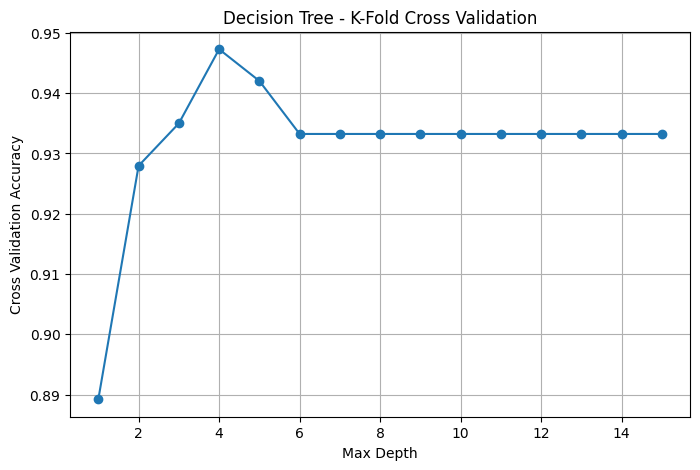

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(depths, results, marker='o')

plt.xlabel("Max Depth")
plt.ylabel("Cross Validation Accuracy")
plt.title("Decision Tree - K-Fold Cross Validation")

plt.grid()
plt.show()